# Stress intensity factor for a periodic array of collinear cracks

This notebook works through, with sympy and matplotlib, the Westergaard
stress-function solution for an infinite array of co-planar cracks of
length $2a$, spaced a distance $w$ apart (centre to centre), in a plate
under remote biaxial tension $\sigma_0$ — the same problem as the exercise
sheet on Westergaard stress functions.

The Westergaard function for this geometry is
$$
Z(z) = \frac{\sigma_0 \sin\dfrac{\pi z}{w}}
{\sqrt{\sin^2\dfrac{\pi z}{w} - \sin^2\dfrac{\pi a}{w}}}, \qquad z = x+iy,
$$
with $\sigma_{yy}(x,0) = \mathrm{Re}\,Z(x,0)$ ahead of the crack tips.

Run it however is easiest for you:

- **In a browser, nothing installed:**
  https://cfni-dtu.github.io/41526-notebooks/lab/index.html?path=lecture04/Westergaard_periodic_cracks.ipynb
- **Locally**, with any Jupyter install
  (`pip install numpy matplotlib sympy jupyterlab`, then `jupyter lab`).


In [1]:
try:
    import sympy as sp
except ImportError:
    import micropip
    await micropip.install("sympy")
    import sympy as sp

import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()


## Step 1 — the Westergaard function and the remote field

Far from the cracks ($y\to\infty$), $Z(z)$ should reduce to the applied
remote stress $\sigma_0$, for any $x$. We take this limit symbolically.

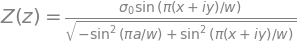

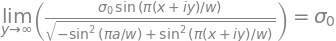

In [2]:
sigma0, a, w, x, y = sp.symbols('sigma_0 a w x y', positive=True)
z = x + sp.I*y

Z = sigma0*sp.sin(sp.pi*z/w) / sp.sqrt(sp.sin(sp.pi*z/w)**2 - sp.sin(sp.pi*a/w)**2)
display(sp.Eq(sp.Symbol('Z(z)'), Z))

remote_limit = sp.limit(sp.simplify(Z.rewrite(sp.exp)), y, sp.oo)
display(sp.Eq(sp.Limit(Z, y, sp.oo), remote_limit))


## Step 2 — a contour plot of $\sigma_{22}$, and a branch-cut trap

The crack array has period $w$, so the physical field
$\sigma_{22}(x,y) = \mathrm{Re}\,Z(z) + y\,\mathrm{Im}\,Z'(z)$ must repeat
exactly every $w$. Evaluating $Z(z)$ pointwise with the principal-branch
square root doesn't give that directly: its branch cut runs straight
through each crack centre, unrelated to the crack geometry, flipping the
sign of $Z$ once every period. Since we know exactly where that happens,
we can undo it directly: multiply by $(-1)^{\lfloor x/w\rfloor}$.

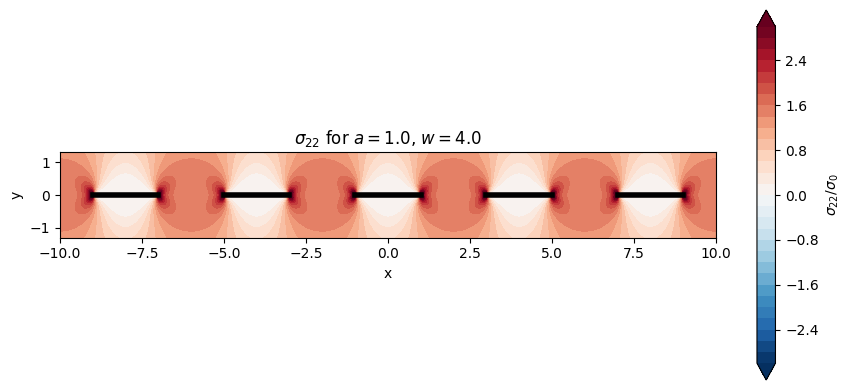

In [3]:
Zp = sp.diff(Z, x)   # dZ/dz = dZ/dx for analytic Z(x+iy)

a_val, w_val, sigma0_val = 1.0, 4.0, 1.0
subs_num = {a: a_val, w: w_val, sigma0: sigma0_val}
Z_num = sp.lambdify((x, y), Z.subs(subs_num), 'numpy')
Zp_num = sp.lambdify((x, y), Zp.subs(subs_num), 'numpy')

x_vals = np.linspace(-2.5*w_val, 2.5*w_val, 500)
y_vals = np.linspace(-1.3, 1.3, 120)   # even count: never lands exactly on y=0
X, Y = np.meshgrid(x_vals, y_vals, indexing='ij')

sign = (-1.0)**np.floor(X/w_val)   # undoes the spurious per-period sign flip
sigma22 = np.real(sign*Z_num(X, Y)) + Y*np.imag(sign*Zp_num(X, Y))

fig, ax = plt.subplots(figsize=(9, 4))
cf = ax.contourf(X, Y, sigma22, levels=np.linspace(-3, 3, 31), extend='both', cmap='RdBu_r')
fig.colorbar(cf, ax=ax, label=r'$\sigma_{22}/\sigma_0$')
for n in range(-2, 3):
    ax.plot([n*w_val - a_val, n*w_val + a_val], [0, 0], color='k', lw=4)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
ax.set_title(f'$\sigma_{{22}}$ for $a={a_val}$, $w={w_val}$')
fig.tight_layout()
plt.show()


## Step 3 — the near-tip limit gives $K_I$

Substituting $x=a+r$ and taking the limit of $\sigma_{yy}(r)^2\cdot2\pi r$
as $r\to0^+$ gives $K_I^2$; its square root gives $K_I$.

In [4]:
r = sp.symbols('r', positive=True)
sigma_yy_r = Z.subs({x: a + r, y: 0})

K_I_sq = sp.simplify(sp.limit(sigma_yy_r**2 * 2*sp.pi*r, r, 0, '+'))
display(sp.Eq(sp.Symbol('K_I__2'), K_I_sq))

K_I = sp.sqrt(K_I_sq)
display(sp.Eq(sp.Symbol('K_I'), K_I))


## Step 4 — the periodic-array field vs. the $K$-field

We plot the exact $\sigma_{yy}(x,0)$ ahead of one crack tip, from that tip
to the neighbouring crack, against the near-tip approximation
$K_I/\sqrt{2\pi r}$, using the same $a=1$, $w=4$ as in Step 2
(so $a/w=0.25$: a moderately close-packed array, not an isolated crack).

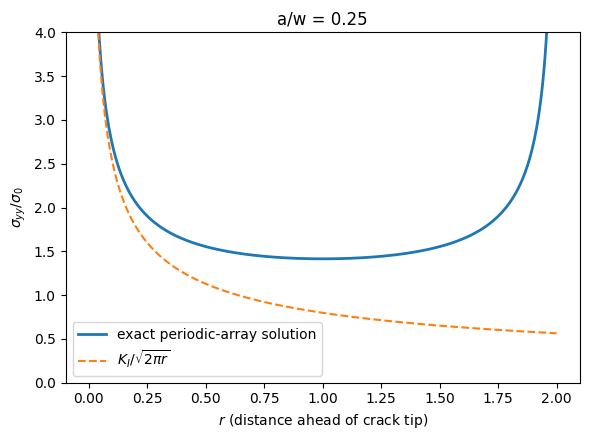

In [5]:
sigma_yy_num = sp.lambdify(r, sigma_yy_r.subs({a: a_val, w: w_val, sigma0: sigma0_val}), 'numpy')
K_I_val = float(K_I.subs({a: a_val, w: w_val, sigma0: sigma0_val}))

r_vals = np.linspace(1e-4, w_val - 2*a_val, 400)
sigma_exact = sigma_yy_num(r_vals)
sigma_Kfield = K_I_val / np.sqrt(2*np.pi*r_vals)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(r_vals, sigma_exact, lw=2, label='exact periodic-array solution')
ax.plot(r_vals, sigma_Kfield, lw=1.5, ls='--', label=r'$K_I/\sqrt{2\pi r}$')
ax.set_xlabel(r'$r$ (distance ahead of crack tip)')
ax.set_ylabel(r'$\sigma_{yy}/\sigma_0$')
ax.set_ylim(0, 4)
ax.set_title(f'a/w = {a_val/w_val:.2f}')
ax.legend()
fig.tight_layout()
plt.show()


## Step 5 — interaction between neighbouring cracks

Factoring $K_I = \sigma_0\sqrt{\pi a}\,f(a/w)$ isolates the single-crack
Griffith value $\sigma_0\sqrt{\pi a}$ from a dimensionless amplification
factor $f(a/w)$ due to the neighbouring cracks. We get $f$ straight from
the $K_I$ derived above, by dividing it out.

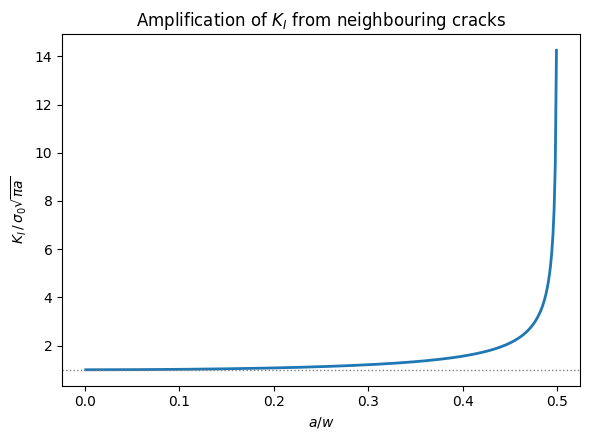

In [6]:
f_expr = sp.simplify(K_I / (sigma0*sp.sqrt(sp.pi*a)))
display(sp.Eq(sp.Symbol('f(a/w)'), f_expr))

aw = np.linspace(1e-3, 0.499, 400)
f = np.sqrt((1/(np.pi*aw)) * np.tan(np.pi*aw))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(aw, f, lw=2)
ax.axhline(1, ls=':', color='gray', lw=1)
ax.set_xlabel(r'$a/w$')
ax.set_ylabel(r'$K_I \,/\, \sigma_0\sqrt{\pi a}$')
ax.set_title('Amplification of $K_I$ from neighbouring cracks')
fig.tight_layout()
plt.show()


## Takeaways

- The symbolic limit $y\to\infty$ of $Z(z)$ reproduces $\sigma_0$ exactly,
  recovering the applied remote biaxial tension.
- $\sigma_{22}(x,y)$ is genuinely periodic with period $w$, matching the
  crack array itself — evaluating $Z(z)$ pointwise with the principal
  square root hides this behind a spurious sign flip every ligament,
  undone by multiplying by $(-1)^{\lfloor x/w\rfloor}$.
- The $r\to0^+$ limit of $\sigma_{yy}(r)^2\cdot2\pi r$ gives $K_I^2$, and
  hence $K_I$, in closed form directly.
- Close to the tip the periodic-array solution collapses onto the
  universal $K$-field; further away it deviates because of the
  neighbouring cracks.
- $K_I$ exceeds the single-crack value $\sigma_0\sqrt{\pi a}$ once
  $a/w$ becomes appreciable, diverging as the cracks approach
  coalescence ($a/w\to0.5$) — closely spaced cracks amplify each
  other's stress intensity.